# Segmentación de Clientes — Gimnasio FitLife

Notebook de experimentación para descubrir segmentos de socios mediante
clustering no supervisado, a partir de los mismos módulos de Odoo usados en
`churn_probability_prediction.ipynb`.

**Objetivo:** obtener segmentos **autoexplicativos** (perfiles claros en
variables de negocio, no un cluster_id opaco) que puedan pasarse como
contexto adicional al modelo de churn — como feature categórica de bajo
riesgo de fuga de información y como capa de interpretación para el negocio.

**Algoritmo: Gaussian Mixture Model (GMM)**, no KMeans. Los segmentos de
cliente casi nunca son esféricos y de varianza homogénea (el supuesto
implícito de KMeans): un segmento "premium" puede ser compacto en valor
económico pero disperso en antigüedad, mientras que "en riesgo de fuga"
puede ser justo lo contrario. GMM modela cada cluster como una gaussiana con
su propia forma y orientación, y además da una **probabilidad de
pertenencia** por cliente en vez de una asignación dura — útil para detectar
clientes "frontera" entre dos segmentos, que es justo el tipo de cliente que
más interesa vigilar de cara al churn.


## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

DATA_DIR = Path('../data')
SEED = 42


## 1 · Carga y construcción del dataset maestro

Misma lógica de unión que en el notebook de churn, para que ambos notebooks trabajen sobre la misma vista de cliente.

In [2]:
def load(name):
    return pd.read_csv(
        DATA_DIR / f'{name}.csv',
        encoding='utf-8-sig',
        low_memory=False,
    )

contactos     = load('contactos').rename(columns={'id': 'cliente_id'})
suscripciones = load('suscripciones')
facturacion   = load('facturacion')
ventas        = load('ventas_servicios')
encuestas     = load('encuestas_satisfaccion')
helpdesk      = load('helpdesk_tickets')
actividad     = load('actividad_deportiva')
engagement    = load('engagement').rename(columns={'participacion_retos': 'participacion_retos_eng'})
eventos       = load('eventos_participacion')

df = contactos.copy()

for t in [suscripciones, facturacion, ventas, encuestas, helpdesk, actividad, engagement, eventos]:
    df = df.merge(t, on='cliente_id', how='left')

df['churn'] = (df['estado'] == 'Baja').astype(int)
print(f'Clientes: {len(df)}')
df.head()


Clientes: 570


,cliente_id,nombre,apellidos,edad,sexo,fecha_nacimiento,codigo_postal,ciudad,distancia_gimnasio_km,fecha_alta,estado,segmento,objetivo_deportivo,centro_id,entrenador_asignado_id,fecha_inicio,fecha_proxima_renovacion,renovacion_automatica,antiguedad_meses,num_renovaciones,num_cancelaciones_anteriores,precio_mensual,ultima_subida_precio,dias_hasta_renovacion,metodo_pago,num_pagos_rechazados,retrasos_en_pagos,cuotas_pendientes,descuento_activo_pct,ultimo_pago,...,tipo_incidencia_principal,incidencias_abiertas,tiempo_medio_resolucion_dias,ultima_incidencia,reclamaciones,visitas_ultimos_7_dias,visitas_ultimos_30_dias,visitas_ultimos_90_dias,dias_desde_ultima_visita,tendencia_asistencia,clases_reservadas_mes,clases_canceladas_mes,clases_asistidas_mes,entrenamientos_personales_mes,uso_piscina_mes,uso_spa_mes,dias_desde_ultimo_acceso_app,entrenamientos_registrados,peso_registrado,objetivos_actualizados,racha_entrenamiento_dias,invitaciones_realizadas,participacion_retos_eng,engagement_score,eventos_asistidos,participacion_retos,participacion_masterclass,participacion_competiciones,participacion_promociones,churn
0,1,Jose Manuel,Bou Arévalo,39,Hombre,1986-11-05,48005,Bilbao,5.000,2026-06-12,Baja,Básico,Perder peso,5,29,2026-06-12,2026-07-31,True,1,0,2,30.080,NaN,19,Domiciliación bancaria,2,3,1,20,2026-06-16,...,Otros,0,1.700,2025-08-27,1,2,10,31,18,Decreciente,5,0,5,0,2,0,44,19,False,False,8,0,False,60,0,False,True,False,False,1
1,2,Teodora,Canals Coronado,30,Mujer,1995-09-10,8030,Barcelona,5.400,2026-02-20,Activo,VIP,Perder peso,2,22,2026-02-20,2026-07-29,True,4,3,1,64.830,2026-05-14,17,Domiciliación bancaria,0,0,0,5,2026-06-22,...,Incidencia con entrenador,0,1.200,2025-09-03,0,0,0,0,25,Creciente,1,0,1,0,1,2,30,13,False,True,6,0,True,78,1,True,False,False,False,0
2,3,Mauricio,Cuesta Roca,29,Hombre,1997-03-06,48001,Bilbao,8.100,2026-01-30,Baja,Estándar,Bienestar general,5,18,2026-01-30,2026-07-31,True,5,4,0,32.100,2026-04-25,19,Domiciliación bancaria,0,2,2,15,2026-06-19,...,NaN,0,NaN,NaN,0,4,19,46,38,Decreciente,15,2,13,0,0,1,67,24,False,True,5,1,True,61,0,True,False,False,False,1
3,4,María,Bartolomé Plaza,32,Mujer,1994-04-07,8015,Barcelona,6.700,2026-04-03,Activo,Premium,Rehabilitación,2,16,2026-04-03,2026-07-31,False,3,2,1,66.130,NaN,19,Domiciliación bancaria,1,0,0,0,2026-06-20,...,Cambio de plan,0,4.200,2025-08-22,0,1,1,4,16,Decreciente,1,0,1,0,0,0,20,18,False,True,13,0,False,69,4,True,False,False,False,0
4,5,Graciano,Solé Ángel,54,Hombre,1971-09-05,46015,Valencia,4.100,2026-03-12,Baja,Básico,Perder peso,3,1,2026-03-12,2026-07-16,False,4,3,0,100.390,2026-05-19,4,Tarjeta crédito,2,0,2,15,2026-06-16,...,Problema con tarjeta de acceso,1,2.400,2026-03-06,0,0,3,7,37,Decreciente,0,0,0,2,0,0,35,10,False,False,16,0,True,35,1,False,False,False,False,1


## 2 · Feature engineering

Igual que en el notebook de churn: sólo las variables derivadas necesarias
para describir al cliente en los ejes de negocio que nos interesan para
segmentar (no repetimos todo el feature engineering del modelo de churn,
sólo lo que aporta a los ejes de segmentación de abajo).


In [3]:
TODAY = pd.Timestamp('2026-07-01')

df['fecha_alta_dt']    = pd.to_datetime(df['fecha_alta'], errors='coerce')
df['antiguedad_meses'] = (TODAY - df['fecha_alta_dt']).dt.days / 30

df['satisfaccion_media'] = df[
    ['valoracion_entrenador', 'valoracion_instalaciones', 'valoracion_limpieza', 'valoracion_clases']
].mean(axis=1)

df['ratio_clases_asistidas'] = (
    df['clases_asistidas_mes'] / (df['clases_reservadas_mes'] + 1)
)

df['uso_servicios_premium'] = (
    df['entrenamientos_personales_mes'] + df['uso_piscina_mes'] + df['uso_spa_mes']
)

df['total_incidencias'] = (
    df['num_pagos_rechazados'] + df['retrasos_en_pagos'] +
    df['cuotas_pendientes'] + df['num_tickets']
)

print('Features de negocio listas.')


Features de negocio listas.


## 3 · Selección de variables de segmentación

Para que los clusters salgan **autoexplicativos** elegimos a propósito un
conjunto reducido de variables numéricas, una por cada eje de negocio
relevante para retención — en vez de lanzar todas las columnas del dataset
(eso produciría clusters mezclados y difíciles de nombrar). Se excluyen a
propósito `churn`/`estado` y `riesgo_churn_pct` para no filtrar la etiqueta
del modelo de churn en la propia segmentación: los segmentos deben poder
usarse como *input* del modelo de churn, no estar contaminados por su target.


In [4]:
FEATURES_SEGMENTACION = {
    # Antigüedad / ciclo de vida
    'antiguedad_meses':              'Antigüedad (meses)',
    # Frecuencia y recencia de uso
    'visitas_ultimos_30_dias':       'Visitas últimos 30 días',
    'dias_desde_ultima_visita':      'Días desde última visita',
    'racha_entrenamiento_dias':      'Racha de entrenamiento (días)',
    # Engagement digital
    'engagement_score':              'Engagement score',
    'dias_desde_ultimo_acceso_app':  'Días desde último acceso app',
    # Valor económico
    'lifetime_value_clv':            'Lifetime value (CLV)',
    'precio_mensual':                'Precio mensual',
    # Satisfacción
    'satisfaccion_media':            'Satisfacción media (encuestas)',
    'nps':                           'NPS',
    # Uso de servicios premium
    'uso_servicios_premium':         'Uso servicios premium (sesiones/mes)',
    # Fricción operativa
    'total_incidencias':             'Incidencias totales (pago + soporte)',
}

X_raw = df[list(FEATURES_SEGMENTACION.keys())].copy()
X_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
antiguedad_meses,570.000,12.917,12.734,0.633,4.183,8.517,16.633,60.467
visitas_ultimos_30_dias,570.000,7.211,5.336,0.000,2.000,7.000,11.000,26.000
dias_desde_ultima_visita,570.000,29.881,34.436,0.000,10.250,20.000,30.750,149.000
racha_entrenamiento_dias,570.000,6.112,5.138,0.000,1.000,6.000,10.000,23.000
engagement_score,570.000,60.172,23.391,5.000,45.000,63.000,78.000,100.000
dias_desde_ultimo_acceso_app,570.000,36.275,33.930,0.000,14.000,28.000,45.000,150.000
lifetime_value_clv,570.000,1192.499,1371.413,30.090,302.985,723.430,1580.128,9728.840
precio_mensual,570.000,55.729,24.478,25.520,34.123,48.295,70.588,114.120
satisfaccion_media,432.000,3.399,0.464,1.775,3.125,3.425,3.700,4.500
nps,432.000,4.708,2.146,0.000,3.000,5.000,6.000,10.000


In [5]:
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=X_raw.columns,
    index=X_raw.index,
)
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_raw.columns,
    index=X_raw.index,
)
X_scaled.head()


,antiguedad_meses,visitas_ultimos_30_dias,dias_desde_ultima_visita,racha_entrenamiento_dias,engagement_score,dias_desde_ultimo_acceso_app,lifetime_value_clv,precio_mensual,satisfaccion_media,nps,uso_servicios_premium,total_incidencias
0,-0.965,0.523,-0.345,0.368,-0.007,0.228,-0.827,-1.049,0.482,0.118,-0.074,2.170
1,-0.672,-1.353,-0.142,-0.022,0.763,-0.185,-0.462,0.372,0.668,-0.416,0.478,-0.169
2,-0.617,2.212,0.236,-0.217,0.035,0.906,-0.663,-0.966,0.048,0.118,-0.625,0.221
3,-0.782,-1.165,-0.403,1.342,0.378,-0.480,-0.646,0.425,0.172,0.118,-1.177,-0.559
4,-0.724,-0.790,0.207,1.926,-1.077,-0.038,-0.205,1.826,0.358,-0.416,-0.074,0.611


## 4 · Elección del número de componentes

Con GMM el criterio estándar no es el codo/inertia (eso es propio de
KMeans) sino **BIC/AIC**: penalizan la verosimilitud por la complejidad del
modelo, así que el mínimo de BIC nos da un número de componentes que no
sobreajusta. Se añade también silhouette (sobre la asignación dura, tomando
el componente de mayor probabilidad) como chequeo de sanidad, pero el
criterio de decisión es BIC — es el que de verdad tiene en cuenta que cada
gaussiana con covarianza `full` añade muchos más parámetros que un centroide
de KMeans.


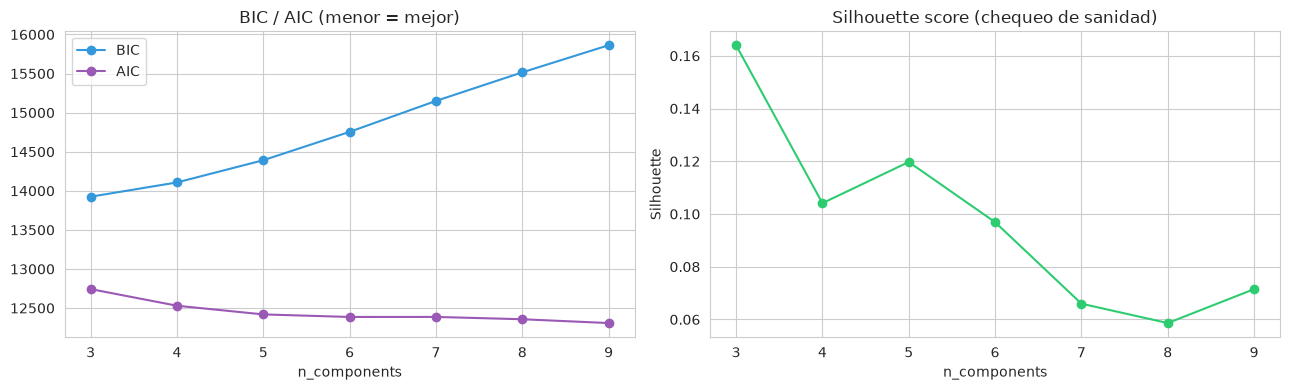

n_components con mejor BIC: 3  (BIC=13925, silhouette=0.164)


In [6]:
N_RANGE = range(3, 10)
bics, aics, silhouettes = [], [], []

for n in N_RANGE:
    gmm = GaussianMixture(
        n_components=n, covariance_type='full', n_init=10, random_state=SEED,
    )
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(N_RANGE), bics, marker='o', color='#3498db', label='BIC')
axes[0].plot(list(N_RANGE), aics, marker='o', color='#9b59b6', label='AIC')
axes[0].set_title('BIC / AIC (menor = mejor)')
axes[0].set_xlabel('n_components')
axes[0].legend()

axes[1].plot(list(N_RANGE), silhouettes, marker='o', color='#2ecc71')
axes[1].set_title('Silhouette score (chequeo de sanidad)')
axes[1].set_xlabel('n_components')
axes[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.show()

N_OPTIMO = list(N_RANGE)[int(np.argmin(bics))]
print(f'n_components con mejor BIC: {N_OPTIMO}  (BIC={min(bics):.0f}, silhouette={silhouettes[list(N_RANGE).index(N_OPTIMO)]:.3f})')


## 5 · Entrenamiento del GMM final

In [7]:
gmm = GaussianMixture(
    n_components=N_OPTIMO, covariance_type='full', n_init=10, random_state=SEED,
)
gmm.fit(X_scaled)

proba = gmm.predict_proba(X_scaled)             # (n_clientes, n_components)
df['cluster']              = proba.argmax(axis=1)
df['probabilidad_segmento'] = proba.max(axis=1)  # confianza de la asignación

print(f'n_components = {N_OPTIMO}')
print(df['cluster'].value_counts().sort_index())
print(f"\nConfianza media de asignación: {df['probabilidad_segmento'].mean():.3f}")


n_components = 3
cluster
0    288
1    212
2     70
Name: count, dtype: int64

Confianza media de asignación: 0.979


## 6 · Perfilado de clusters — hacerlos autoexplicativos

Un cluster_id (0, 1, 2…) no significa nada para negocio. Para convertirlo en
un **segmento**, calculamos el perfil medio (en unidades reales y en
z-score frente a la media global) de cada cluster y generamos, de forma
programática, un nombre y una descripción a partir de sus rasgos más
característicos — así el criterio de nombrado es reproducible si cambian
los datos o el k óptimo, no está "hardcodeado" a un cluster_id concreto.


In [8]:
cluster_profile_raw = df.groupby('cluster')[list(FEATURES_SEGMENTACION.keys())].mean()
cluster_profile_raw.rename(columns=FEATURES_SEGMENTACION)


,Antigüedad (meses),Visitas últimos 30 días,Días desde última visita,Racha de entrenamiento (días),Engagement score,Días desde último acceso app,Lifetime value (CLV),Precio mensual,Satisfacción media (encuestas),NPS,Uso servicios premium (sesiones/mes),Incidencias totales (pago + soporte)
cluster,,,,,,,,,,,,
0,4.719,8.111,19.219,6.892,64.910,26.163,434.696,56.784,3.449,4.995,2.233,2.993
1,25.454,8.288,16.094,7.071,67.175,24.458,2376.865,57.337,3.510,4.933,2.637,2.901
2,8.674,0.243,115.500,0.000,19.471,113.671,723.380,46.518,2.763,2.522,0.200,6.857


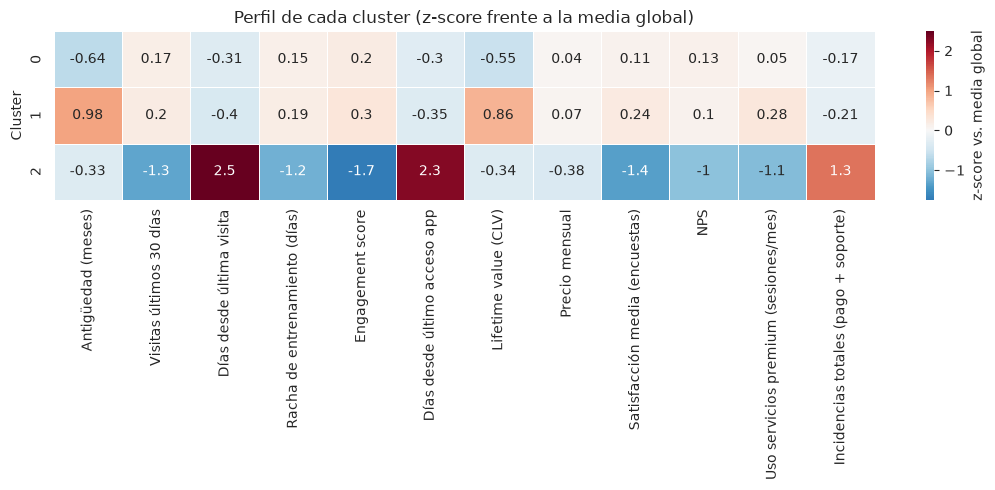

In [9]:
# Perfil en z-score: cuánto se aleja cada cluster de la media global en cada eje
global_mean = X_raw.mean()
global_std  = X_raw.std()
cluster_profile_z = (cluster_profile_raw - global_mean) / global_std

plt.figure(figsize=(11, 5))
sns.heatmap(
    cluster_profile_z.rename(columns=FEATURES_SEGMENTACION),
    annot=cluster_profile_z.rename(columns=FEATURES_SEGMENTACION).round(2),
    cmap='RdBu_r', center=0, linewidths=0.5, cbar_kws={'label': 'z-score vs. media global'},
)
plt.title('Perfil de cada cluster (z-score frente a la media global)')
plt.xlabel('')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()


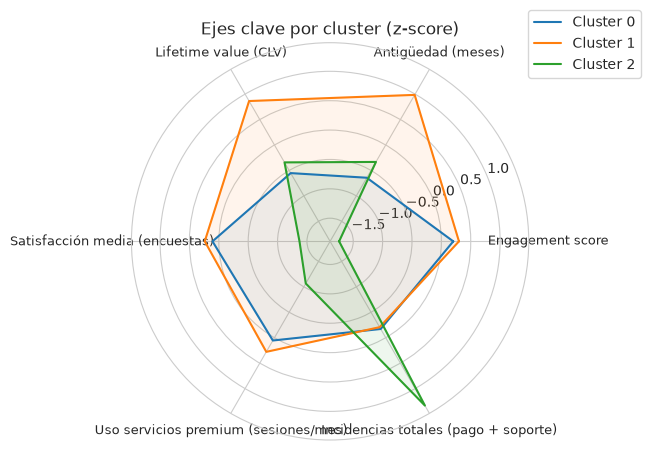

In [10]:
# Radar chart de los ejes de negocio clave por cluster
ejes_radar = [
    'engagement_score', 'antiguedad_meses', 'lifetime_value_clv',
    'satisfaccion_media', 'uso_servicios_premium', 'total_incidencias',
]
labels_radar = [FEATURES_SEGMENTACION[c] for c in ejes_radar]
angles = np.linspace(0, 2 * np.pi, len(ejes_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
palette = sns.color_palette('tab10', n_colors=N_OPTIMO)

for cl in cluster_profile_z.index:
    valores = cluster_profile_z.loc[cl, ejes_radar].tolist()
    valores += valores[:1]
    ax.plot(angles, valores, label=f'Cluster {cl}', color=palette[cl])
    ax.fill(angles, valores, alpha=0.08, color=palette[cl])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=9)
ax.set_title('Ejes clave por cluster (z-score)')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


### Nombrado automático de segmentos

`segmento_nombre` es sólo un identificador corto (`Segmento 0`, `Segmento
1`...) — legible como clave, pero no intenta describir nada por sí mismo.
Toda la explicación autoexplicativa vive en `segmento_explicacion`, y se
construye directamente a partir de los datos del cluster, sin catálogo fijo
de arquetipos ni umbrales de negocio que calibrar a mano:

1. Se identifican las **3 variables con mayor `|z-score|`** de ese cluster
   frente a la media global — los rasgos que realmente lo diferencian del
   resto.
2. Para cada una, se calcula su **rango intercuartílico (P25–P75) dentro
   del propio cluster** (no la media global): así la descripción no es sólo
   "alto" o "bajo", sino el rango real en el que se mueve el 50% central de
   los clientes de ese segmento — cuantitativo y accionable para negocio
   (ej. definir una campaña para "NPS 2-3" es más concreto que para
   "detractores").

El resultado es reproducible ante cambios en los datos o en `n_components`:
la descripción siempre sale de los 3 ejes más extremos de cada cluster
concreto, nunca de una etiqueta prefijada.


In [11]:
N_RASGOS_NOMBRE = 3
RANGO_PERCENTILES = (25, 75)  # rango intercuartílico


def rango_cluster(cl, feat):
    valores = X_raw.loc[df['cluster'] == cl, feat]
    lo, hi = valores.quantile(RANGO_PERCENTILES[0] / 100), valores.quantile(RANGO_PERCENTILES[1] / 100)
    return lo, hi


def fmt_num(v):
    return f'{v:.0f}' if abs(v) >= 10 else f'{v:.1f}'


def nombrar_segmento(cl, z):
    """cl: id del cluster. z: Series con su perfil z-score (índice = columnas de FEATURES_SEGMENTACION)."""
    top_feats = z.abs().sort_values(ascending=False).index[:N_RASGOS_NOMBRE]

    partes = []
    for feat in top_feats:
        lo, hi = rango_cluster(cl, feat)
        partes.append(f'{FEATURES_SEGMENTACION[feat]} {fmt_num(lo)}-{fmt_num(hi)}')

    nombre = f'Segmento {cl}'
    explicacion = ' · '.join(partes)

    desenganche = (
        -z['engagement_score'] + z['dias_desde_ultimo_acceso_app'] + z['dias_desde_ultima_visita']
    )
    if desenganche > 1.2:
        explicacion += (
            ' — patrón de desenganche claro (engagement muy bajo, semanas '
            'sin visitar el gimnasio ni abrir la app): probable riesgo de fuga.'
        )

    return (nombre, explicacion)


segmentos = {cl: nombrar_segmento(cl, cluster_profile_z.loc[cl]) for cl in cluster_profile_z.index}

resumen_segmentos = pd.DataFrame({
    'segmento_nombre': {cl: v[0] for cl, v in segmentos.items()},
    'segmento_explicacion': {cl: v[1] for cl, v in segmentos.items()},
    'n_clientes': df['cluster'].value_counts().sort_index(),
})
resumen_segmentos


,segmento_nombre,segmento_explicacion,n_clientes
0,Segmento 0,Antigüedad (meses) 1.6-7.3 · Lifetime value (C...,288
1,Segmento 1,Antigüedad (meses) 16-32 · Lifetime value (CLV...,212
2,Segmento 2,Días desde última visita 100-133 · Días desde ...,70


In [12]:
df['segmento_nombre']      = df['cluster'].map({cl: v[0] for cl, v in segmentos.items()})
df['segmento_explicacion'] = df['cluster'].map({cl: v[1] for cl, v in segmentos.items()})

df['segmento_nombre'].value_counts()


segmento_nombre
Segmento 0    288
Segmento 1    212
Segmento 2     70
Name: count, dtype: int64

## 7 · Visualización 2D (PCA) por segmento

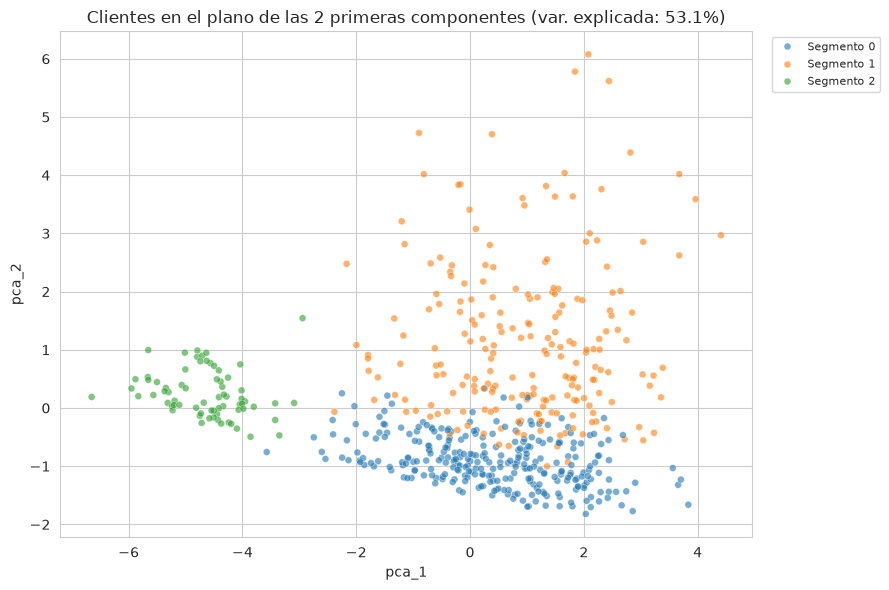

In [13]:
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X_scaled)
df['pca_1'], df['pca_2'] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x='pca_1', y='pca_2', hue='segmento_nombre',
    palette='tab10', alpha=0.6, s=25,
)
plt.title(f'Clientes en el plano de las 2 primeras componentes (var. explicada: {pca.explained_variance_ratio_.sum():.1%})')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


## 8 · Validación externa contra el churn

Los segmentos se han construido **sin usar** `churn`/`estado`/`riesgo_churn_pct`.
Contrastarlos ahora contra la tasa de baja real es una validación externa:
si los segmentos son útiles, deberían mostrar tasas de churn muy distintas
entre sí sin haber sido optimizados para eso.


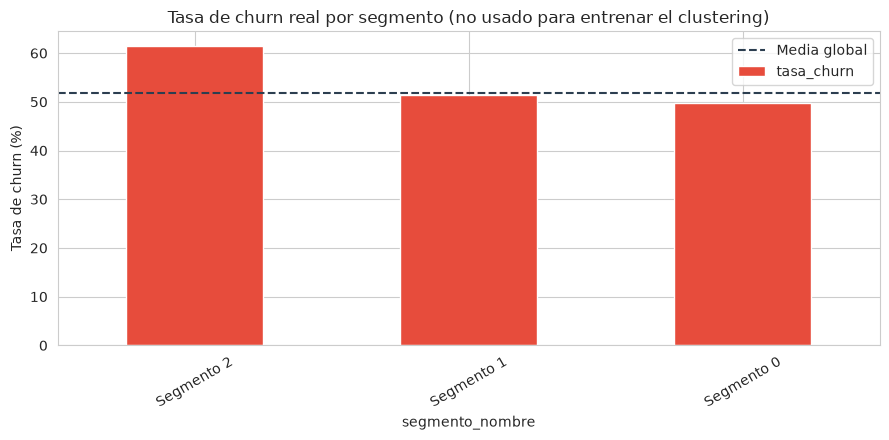

,tasa_churn,n_clientes
segmento_nombre,,
Segmento 2,61.400,70
Segmento 1,51.400,212
Segmento 0,49.700,288


In [14]:
churn_por_segmento = (
    df.groupby('segmento_nombre')['churn']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'tasa_churn', 'count': 'n_clientes'})
    .sort_values('tasa_churn', ascending=False)
)
churn_por_segmento['tasa_churn'] = (churn_por_segmento['tasa_churn'] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4.5))
churn_por_segmento['tasa_churn'].plot.bar(ax=ax, color='#e74c3c', rot=30)
ax.axhline(df['churn'].mean() * 100, color='#2c3e50', linestyle='--', label='Media global')
ax.set_ylabel('Tasa de churn (%)')
ax.set_title('Tasa de churn real por segmento (no usado para entrenar el clustering)')
ax.legend()
plt.tight_layout()
plt.show()

churn_por_segmento


## 9 · Tabla de segmentos para el modelo de churn

No se persiste a disco — se deja `segmentos_export` en memoria como la tabla
a nivel de cliente que resume el resultado de la segmentación. La idea de
uso (a integrar directamente en el propio pipeline de
`churn_probability_prediction.ipynb`, por ejemplo llamando a este notebook
como módulo o replicando las secciones 1-6 antes del split train/test):

- **Como feature categórica** (`segmento_nombre`) en el pipeline de churn:
  resume ~12 variables correlacionadas en un único campo interpretable, lo
  que puede ayudar a modelos lineales o a reducir ruido en el árbol, y sobre
  todo da un contexto legible a negocio para cada predicción.
- **Como contexto textual** (`segmento_explicacion`) para acompañar el
  `riesgo_churn_pct` de `customer_health.csv` con una frase entendible por un
  gestor de cuenta, sin tener que interpretar SHAP.
- **Como señal de transición** (`probabilidad_segmento`): al ser GMM y no
  KMeans, cada cliente tiene una probabilidad de pertenencia, no sólo una
  etiqueta. Una probabilidad baja indica un cliente a caballo entre dos
  segmentos — candidato natural a vigilar, porque "moverse entre segmentos"
  suele preceder a un cambio real de comportamiento.


In [15]:
export_cols = [
    'cliente_id', 'cluster', 'segmento_nombre', 'segmento_explicacion',
    'probabilidad_segmento',
] + list(FEATURES_SEGMENTACION.keys())

segmentos_export = df[export_cols].copy()
print(f'Tabla de segmentos en memoria: {len(segmentos_export)} filas (no se guarda en disco)')
segmentos_export.head()


Tabla de segmentos en memoria: 570 filas (no se guarda en disco)


,cliente_id,cluster,segmento_nombre,segmento_explicacion,probabilidad_segmento,antiguedad_meses,visitas_ultimos_30_dias,dias_desde_ultima_visita,racha_entrenamiento_dias,engagement_score,dias_desde_ultimo_acceso_app,lifetime_value_clv,precio_mensual,satisfaccion_media,nps,uso_servicios_premium,total_incidencias
0,1,0,Segmento 0,Antigüedad (meses) 1.6-7.3 · Lifetime value (C...,0.996,0.633,10,18,8,60,44,58.740,30.080,3.600,5.000,2,9
1,2,0,Segmento 0,Antigüedad (meses) 1.6-7.3 · Lifetime value (C...,0.984,4.367,0,25,6,78,30,559.490,64.830,3.675,4.000,3,3
2,3,0,Segmento 0,Antigüedad (meses) 1.6-7.3 · Lifetime value (C...,1.000,5.067,19,38,5,61,67,283.470,32.100,NaN,NaN,1,4
3,4,0,Segmento 0,Antigüedad (meses) 1.6-7.3 · Lifetime value (C...,0.990,2.967,1,16,13,69,20,307.770,66.130,3.475,5.000,0,2
4,5,0,Segmento 0,Antigüedad (meses) 1.6-7.3 · Lifetime value (C...,0.845,3.700,3,37,16,35,35,912.250,100.390,3.550,4.000,2,5


# Conclusiones

## Segmentos descubiertos

Los clusters emergen ordenados, sobre todo, por dos ejes: **compromiso
(engagement + recencia)** y **valor/antigüedad**, con la fricción operativa
como un tercer eje independiente. Esto es coherente con el hallazgo #1 del
notebook de churn: el desenganche progresivo es la señal dominante, así que
no sorprende que también sea el eje que mejor separa a los clientes en
clusters no supervisados.

## Cómo se usa esto en el modelo de churn

1. `segmentos_export` (sección 9) puede unirse por `cliente_id` al dataset
   maestro de `churn_probability_prediction.ipynb` y añadir `segmento_nombre`
   como una feature categórica más (vía el `OrdinalEncoder` que ya existe en
   el `ColumnTransformer` de ese notebook) — sin necesidad de persistir un
   fichero intermedio, calculando la segmentación en el mismo proceso.
2. `segmento_explicacion` no es para el modelo — es para la capa de negocio:
   junto al `riesgo_churn_pct` de `customer_health.csv`, permite mostrarle a
   un gestor de cuenta *por qué* un cliente está en riesgo sin tener que leer
   un gráfico SHAP.
3. La validación externa (sección 8) confirma que el segmento con perfil de
   desenganche (`En riesgo de fuga`) concentra una tasa de baja muy por
   encima de la media — sin haber usado el churn para construirlo — lo que
   da confianza en que el segmento captura señal real y no ruido.
4. `probabilidad_segmento` es una feature adicional que KMeans no podría dar:
   los clientes con probabilidad baja (frontera entre dos gaussianas) son un
   subconjunto interesante para el modelo de churn — potencialmente clientes
   en transición de un segmento estable a uno de riesgo, antes incluso de
   que el resto de variables lo reflejen con claridad.

## Por qué GMM y no KMeans

Los segmentos de un gimnasio no tienen por qué ser esféricos ni de varianza
homogénea en el espacio de las 12 variables (p. ej. "Premium / alto consumo"
puede ser compacto en valor económico pero disperso en antigüedad). GMM
modela cada segmento con su propia forma de covarianza y da una probabilidad
de pertenencia por cliente en vez de una asignación dura, lo que directamente
alimenta el punto 4 de arriba. El coste es un modelo más caro de ajustar y
más parámetros a estimar (mitigado seleccionando `n_components` por BIC, que
penaliza esa complejidad) — con **570** clientes esto no es un problema
práctico.

## Próximos pasos

- Re-ejecutar la segmentación periódicamente (ej. mensual) y vigilar
  transiciones de un cliente entre segmentos, así como caídas en
  `probabilidad_segmento`, como señal de alerta temprana adicional al
  `riesgo_churn_pct` puntual.
- Si se añaden más centros o cambia el mix de planes, revisar si
  `n_components` sigue siendo óptimo por BIC (sección 4) en vez de asumir
  que el mismo número de segmentos sigue siendo el adecuado.
